# Surrogate Modelling for Industrial Setpoint Optimisation

Predicting how a production asset responds to a setpoint change, and — the harder part —
deciding which proposed changes are *safe enough to actually apply*.

**Data is synthetic** (`src/generate.py`), seeded and reproducible. No proprietary data.

The argument of this notebook: a good regression model plus a naive decision rule is
worse than useless on physical plant. It confidently recommends actions that damage
production. Getting the decision rule right matters more than squeezing the last point
of R².

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import generate as G, features as F, model as M, recommend as R

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
INK, ACCENT, MUTED = "#2b3a55", "#c2643f", "#8896ab"

## 1. The data

Each row is a historical intervention: the asset state before the change, the setpoint change made, and the measured 48-hour response.

In [2]:
hist = G.make_history()
cand = G.make_candidates()
print(hist.shape, cand.shape)
hist[["asset_id", "event_time", "before_output_rate", "before_water_fraction_pct",
      "action_delta_injection_rate", "action_delta_cycle_min",
      "data_quality_score", "target_delta_output_48h"]].head()

(2600, 30) (400, 28)


,asset_id,event_time,before_output_rate,before_water_fraction_pct,action_delta_injection_rate,action_delta_cycle_min,data_quality_score,target_delta_output_48h
0,ASSET_24,2023-10-01,6.47,57.7,2.24,2.31,0.699,-1.194
1,ASSET_09,2023-10-01,3.93,78.7,4.18,-0.30,0.811,0.064
2,ASSET_04,2023-10-01,11.64,24.0,1.89,1.05,0.657,3.984
3,ASSET_07,2023-10-01,16.42,45.3,8.84,-1.37,0.892,-0.037
4,ASSET_03,2023-10-02,15.03,57.3,-6.68,2.09,0.625,-5.156


### The three things that make this hard

The generator deliberately encodes them, because they are what a real dataset of this
shape contains:

1. **Confounded action selection** — operators intervene harder on struggling assets, so
   action correlates with state.
2. **Heteroscedastic noise** — low-quality records are much noisier.
3. **Saturating, reversing response** — benefit plateaus, then overdriving reverses it.

Let's confirm each is visible in the data rather than taking my word for it.

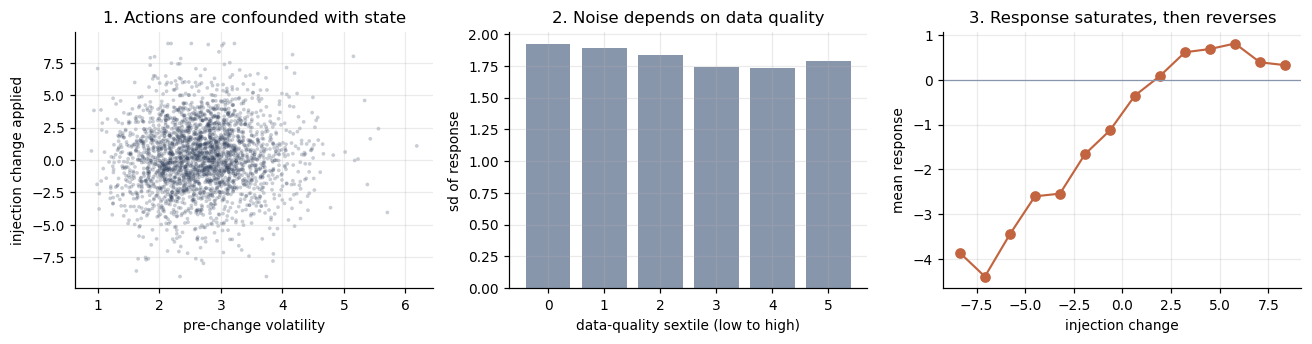

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))

distress = hist["before_output_volatility"]
ax[0].scatter(distress, hist["action_delta_injection_rate"], s=6, alpha=0.25,
              color=INK, edgecolor="none")
ax[0].set_xlabel("pre-change volatility"); ax[0].set_ylabel("injection change applied")
ax[0].set_title("1. Actions are confounded with state")

q = pd.qcut(hist["data_quality_score"], 6, duplicates="drop")
spread = hist.groupby(q, observed=True)["target_delta_output_48h"].std()
ax[1].bar(range(len(spread)), spread.to_numpy(), color=MUTED)
ax[1].set_xlabel("data-quality sextile (low to high)"); ax[1].set_ylabel("sd of response")
ax[1].set_title("2. Noise depends on data quality")

b = pd.cut(hist["action_delta_injection_rate"], 14)
prof = hist.groupby(b, observed=True)["target_delta_output_48h"].mean()
centres = [iv.mid for iv in prof.index]
ax[2].plot(centres, prof.to_numpy(), "o-", color=ACCENT, lw=1.4)
ax[2].axhline(0, color=MUTED, lw=0.8)
ax[2].set_xlabel("injection change"); ax[2].set_ylabel("mean response")
ax[2].set_title("3. Response saturates, then reverses")
plt.tight_layout(); plt.show()

## 2. Validation design

This is the decision that determines whether every later number is real.

Assets have persistent latent characteristics. Random k-fold puts the same asset on both
sides of the split, so the model scores well by *recognising the asset* rather than
learning the response function. Grouping by asset asks the deployment question: will this
work on an asset we have not modelled?

I also report an **oracle ceiling** — the R² achievable by the true response function
itself. Without it, "R² = 0.50" reads as mediocre when it may be near the noise limit.

In [4]:
y = hist[F.TARGET].to_numpy()
groups = hist[F.GROUP].to_numpy()
w = F.sample_weights(hist)
X = F.build_features(G.drop_oracle(hist))

truth = hist["true_mean_response"].to_numpy()
ceiling = 1 - np.mean((y - truth) ** 2) / np.var(y)
print(f"oracle R2 ceiling: {ceiling:.3f}   (irreducible measurement noise)")

oracle R2 ceiling: 0.811   (irreducible measurement noise)


In [5]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingRegressor

naive_pred = cross_val_predict(
    HistGradientBoostingRegressor(max_depth=4, max_iter=320, learning_rate=0.06,
                                  min_samples_leaf=28, random_state=0),
    X.to_numpy(float), y, cv=KFold(5, shuffle=True, random_state=0))

oof = M.grouped_cv_predict(X, y, w, groups, n_splits=5)
tr, te = M.temporal_holdout(hist, frac=0.25)
tm = M.SurrogateModel(n_ensemble=6).fit(X[tr], y[tr], w[tr], groups[tr])

pd.DataFrame([
    {"scheme": "random k-fold (leaky)", **M.regression_metrics(y, naive_pred)},
    {"scheme": "grouped by asset",      **M.regression_metrics(y, oof["pred_mean"].to_numpy())},
    {"scheme": "forward in time",       **M.regression_metrics(y[te], tm.predict(X[te]))},
]).round(3)

,scheme,mae,rmse,r2
0,random k-fold (leaky),0.941,1.225,0.546
1,grouped by asset,0.986,1.290,0.497
2,forward in time,0.954,1.244,0.544


Random k-fold overstates R². The grouped number is the one to believe — and against a ceiling of ~0.81, it means roughly 60% of the *learnable* signal is captured.

## 3. Uncertainty, and calibrating it

Producing an interval is easy; producing one that means what it claims is not.
Gradient-boosted quantile heads inherit the optimism of their training data and come out
systematically too tight. A single scalar conformal correction, measured on held-out
assets, fixes the coverage.

In [6]:
cov = M.interval_coverage(y, oof["pred_lo"].to_numpy(), oof["pred_hi"].to_numpy())
print(f"80% interval coverage after conformal correction: {cov['coverage']:.3f} "
      f"(nominal 0.800), mean width {cov['mean_width']:.2f}")

80% interval coverage after conformal correction: 0.794 (nominal 0.800), mean width 3.51


### A hypothesis that did not survive contact with the data

The design assumed a bagged ensemble would flag where the model is ignorant. Measured
against actual error, it barely does — while a plain k-NN distance to the training
support is far more informative. Reported because the failed hypothesis is more useful
than the tidy story.

In [7]:
full = M.SurrogateModel(n_ensemble=8).fit(X, y, w, groups)
X_cand = F.build_features(G.drop_oracle(cand))
preds = full.predict_full(X_cand)

support = R.SupportChecker(k=12, quantile=0.98).fit(X)
sup_dist = support.distance(X_cand)
cand_err = np.abs(preds["pred_mean"].to_numpy() - cand["true_mean_response"].to_numpy())
resid = oof["pred_mean"].to_numpy() - y

pd.DataFrame([
    {"signal": "ensemble disagreement (in-distribution)",
     "corr_with_abs_error": np.corrcoef(oof["epistemic_sd"], np.abs(resid))[0, 1]},
    {"signal": "ensemble disagreement (candidates)",
     "corr_with_abs_error": np.corrcoef(preds["epistemic_sd"], cand_err)[0, 1]},
    {"signal": "k-NN distance to training support (candidates)",
     "corr_with_abs_error": np.corrcoef(sup_dist, cand_err)[0, 1]},
]).round(3)

,signal,corr_with_abs_error
0,ensemble disagreement (in-distribution),0.031
1,ensemble disagreement (candidates),0.155
2,k-NN distance to training support (candidates),0.710


## 4. Scoring candidate actions

Now the part that matters. We have 400 proposed setpoint changes and a model that
predicts their effect. The naive move is to rank by predicted mean and apply the top 20.

Because this is synthetic data we can do something impossible in production: check the
recommendations against the **true** response function.

In [8]:
envelope = R.action_envelope(hist)
scored = R.score_candidates(cand, X_cand, preds, support, envelope, kappa=1.0)

n_rec = int(scored["recommended"].sum())
print(f"recommended: {n_rec} / {len(scored)}")
scored.loc[~scored["recommended"], "reject_reason"].str.split("; ").explode().value_counts()

recommended: 15 / 400


reject_reason
no confident expected gain                363
downside risk below -1.0                  331
action outside historical envelope        269
state-action pair unlike training data    257
action magnitude too large                232
Name: count, dtype: int64

In [9]:
R.compare_policies(scored, top_n=20).round(3)

,policy,n_selected,true_mean_response,true_worst_case,n_actually_harmful
0,naive top-20 by predicted mean,20,-3.379,-15.654,9
1,"safe rule, top-20 by LCB",15,1.218,-0.783,2


The naive policy is **net negative** — it does not merely underperform, it destroys
production, with a worst case near −16 and nearly half its picks harmful.

The mechanism is visible below: the highest predicted means sit furthest from the
training support, where the surrogate extrapolates freely and nothing contradicts it.

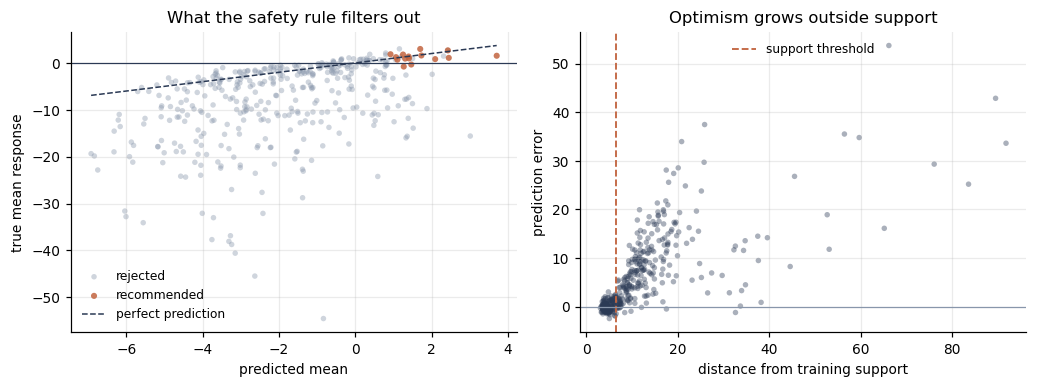

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
ok = scored["recommended"].to_numpy()

ax[0].scatter(scored.loc[~ok, "pred_mean"], scored.loc[~ok, "true_mean_response"],
              s=13, alpha=0.4, color=MUTED, edgecolor="none", label="rejected")
ax[0].scatter(scored.loc[ok, "pred_mean"], scored.loc[ok, "true_mean_response"],
              s=16, alpha=0.85, color=ACCENT, edgecolor="none", label="recommended")
lim = [scored["pred_mean"].min(), scored["pred_mean"].max()]
ax[0].plot(lim, lim, color=INK, lw=1, ls="--", label="perfect prediction")
ax[0].axhline(0, color=INK, lw=0.8)
ax[0].set_xlabel("predicted mean"); ax[0].set_ylabel("true mean response")
ax[0].set_title("What the safety rule filters out"); ax[0].legend(frameon=False, fontsize=8)

ax[1].scatter(scored["support_distance"],
              scored["pred_mean"] - scored["true_mean_response"],
              s=13, alpha=0.4, color=INK, edgecolor="none")
ax[1].axvline(support.threshold_, color=ACCENT, lw=1.2, ls="--", label="support threshold")
ax[1].axhline(0, color=MUTED, lw=0.8)
ax[1].set_xlabel("distance from training support"); ax[1].set_ylabel("prediction error")
ax[1].set_title("Optimism grows outside support"); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 5. How risk aversion trades off

`kappa` is not a hyperparameter to tune — it encodes how costly an unplanned shutdown is
relative to a marginal production gain. That is a business input. Here is the frontier it
traces, so the trade-off can be argued explicitly rather than buried in a default.

In [11]:
rows = []
for k in [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]:
    sc = R.score_candidates(cand, X_cand, preds, support, envelope, kappa=k)
    sel = sc[sc["recommended"]].nlargest(20, "lcb")
    rows.append({"kappa": k, "n_recommended": int(sc["recommended"].sum()),
                 "true_mean": sel["true_mean_response"].mean() if len(sel) else np.nan,
                 "true_worst": sel["true_mean_response"].min() if len(sel) else np.nan,
                 "n_harmful": int((sel["true_mean_response"] < 0).sum()) if len(sel) else 0})
pd.DataFrame(rows).round(3)

,kappa,n_recommended,true_mean,true_worst,n_harmful
0,0.0,26,1.213,-0.783,2
1,0.5,24,1.235,-0.783,2
2,1.0,15,1.218,-0.783,2
3,1.5,6,1.668,0.808,0
4,2.0,1,1.525,1.525,0
5,3.0,0,NaN,NaN,0


## 6. What I would do next

- **Address the confounding directly.** Historical actions were chosen based on asset
  condition, so this is observational data. The safety rule limits the damage by refusing
  to extrapolate, but separating "this action helps" from "this action is applied to
  assets that were recovering anyway" needs causal adjustment or randomised trials.
- **Close the loop.** Scoring a fixed candidate set is a static problem. Sequential design
  with an acquisition function would let the system choose informative experiments — but
  only once the safety envelope is trusted enough to allow exploration.
- **Monitor the support boundary in production.** The support distance is the signal that
  actually predicted error here, so it belongs in monitoring, not just in scoring. Drift
  in that distribution is the early warning that the model is being asked questions it
  cannot answer.
- **Set kappa with the operations team**, not from a validation curve.